## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
# Load dataset
df = pd.read_csv('../data/weather_classification_data.csv')

# Tampilkan informasi dasar
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (13200, 11)

First 5 rows:
   Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   
2         30.0        64         7.0               16.0          clear   
3         38.0        83         1.5               82.0          clear   
4         27.0        74        17.0               66.0       overcast   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2  Winter              3.5    inland   
1               1011.43         7  Spring             10.0    inland   
2               1018.72         5  Spring              5.5  mountain   
3               1026.25         7  Spring              1.0   coastal   
4                990.67         1  Winter              2.5  mountain   

  Weather Type  
0        Rainy  
1       Cloudy  
2        Sunny  
3        Sun

## 3. Eksplorasi Data

Missing Values:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64


Distribusi Weather Type:
Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64


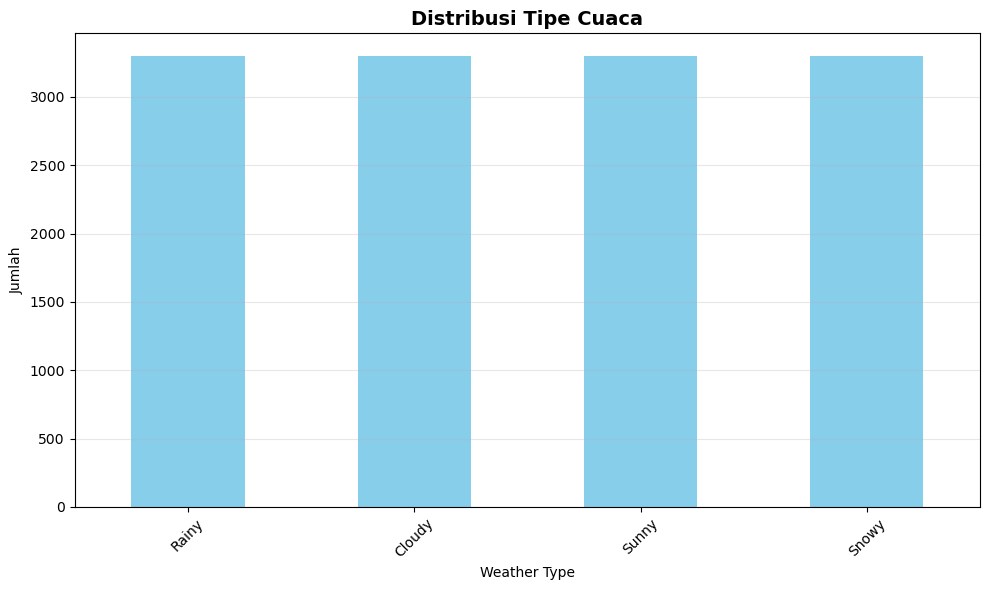

In [3]:
# Cek missing values
print("Missing Values:")
print(df.isnull().sum())

# Cek distribusi target variable
print("\n\nDistribusi Weather Type:")
print(df['Weather Type'].value_counts())

# Visualisasi distribusi weather type
plt.figure(figsize=(10, 6))
df['Weather Type'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribusi Tipe Cuaca', fontsize=14, fontweight='bold')
plt.xlabel('Weather Type')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

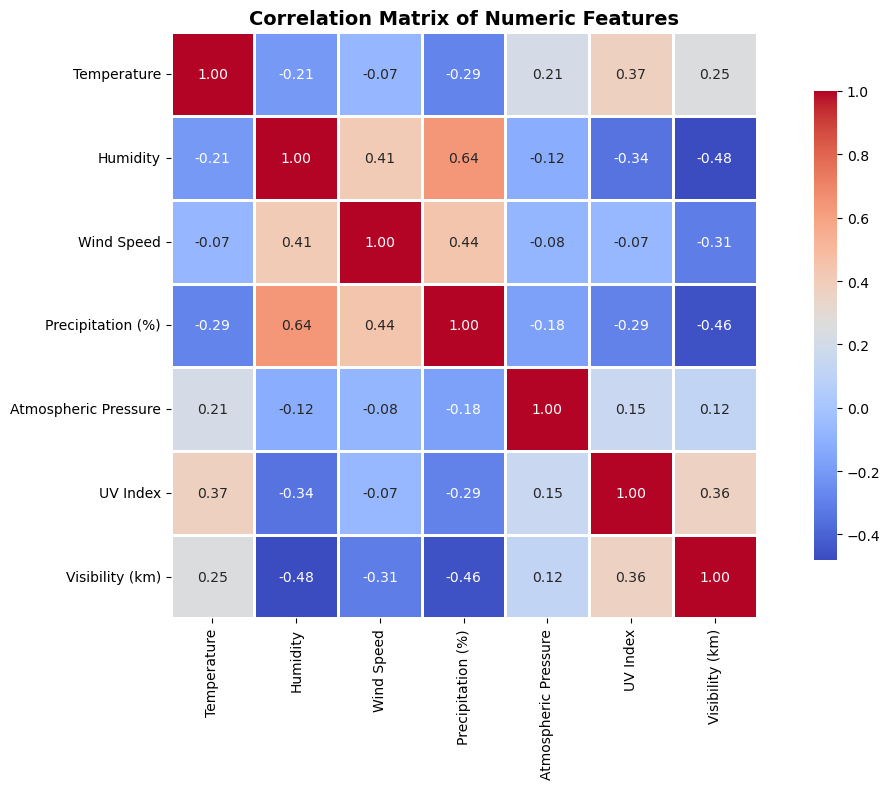

In [4]:
# Visualisasi korelasi fitur numerik
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [5]:
# Encode categorical features
label_encoders = {}
categorical_cols = ['Cloud Cover', 'Season', 'Location']

df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"\n{col} encoding:")
    for i, label in enumerate(le.classes_):
        print(f"  {label}: {i}")

# Encode target variable
le_target = LabelEncoder()
df_encoded['Weather Type'] = le_target.fit_transform(df['Weather Type'])
print("\n\nWeather Type encoding:")
for i, label in enumerate(le_target.classes_):
    print(f"  {label}: {i}")

print("\n\nEncoded Data Shape:", df_encoded.shape)
print(df_encoded.head())


Cloud Cover encoding:
  clear: 0
  cloudy: 1
  overcast: 2
  partly cloudy: 3

Season encoding:
  Autumn: 0
  Spring: 1
  Summer: 2
  Winter: 3

Location encoding:
  coastal: 0
  inland: 1
  mountain: 2


Weather Type encoding:
  Cloudy: 0
  Rainy: 1
  Snowy: 2
  Sunny: 3


Encoded Data Shape: (13200, 11)
   Temperature  Humidity  Wind Speed  Precipitation (%)  Cloud Cover  \
0         14.0        73         9.5               82.0            3   
1         39.0        96         8.5               71.0            3   
2         30.0        64         7.0               16.0            0   
3         38.0        83         1.5               82.0            0   
4         27.0        74        17.0               66.0            2   

   Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  \
0               1010.82         2       3              3.5         1   
1               1011.43         7       1             10.0         1   
2               1018.72         5       1  

In [6]:
# Split features and target
X = df_encoded.drop('Weather Type', axis=1)
y = df_encoded['Weather Type']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (13200, 10)
Target shape: (13200,)

Feature columns:
['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location']


In [7]:
# Split data menjadi training dan testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining target distribution:")
print(pd.Series(y_train).value_counts())
print("\nTesting target distribution:")
print(pd.Series(y_test).value_counts())

Training set size: (10560, 10)
Testing set size: (2640, 10)

Training target distribution:
Weather Type
2    2640
3    2640
1    2640
0    2640
Name: count, dtype: int64

Testing target distribution:
Weather Type
1    660
0    660
3    660
2    660
Name: count, dtype: int64


In [8]:
# Feature Scaling - KNN sensitive to feature scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original Training data sample:")
print(X_train.head())
print("\n\nScaled Training data sample:")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

Original Training data sample:
       Temperature  Humidity  Wind Speed  Precipitation (%)  Cloud Cover  \
13143         -7.0        70         1.5               72.0            2   
5670          -2.0        60        13.5               75.0            2   
1113           1.0        95         4.0               97.0            2   
2602          20.0        59        10.0               16.0            3   
10526         29.0        32         3.0               15.0            0   

       Atmospheric Pressure  UV Index  Season  Visibility (km)  Location  
13143                989.30         1       3              2.0         2  
5670                 997.81         1       3              4.5         2  
1113                 987.61         0       3              3.0         1  
2602                1015.12        10       2              9.5         2  
10526               1012.12        11       1              6.0         0  


Scaled Training data sample:
   Temperature  Humidity  Wind 

## 5. Mencari Nilai K Optimal

K=1: Train Accuracy=1.0000, Test Accuracy=0.8973
K=6: Train Accuracy=0.9251, Test Accuracy=0.8977
K=6: Train Accuracy=0.9251, Test Accuracy=0.8977
K=11: Train Accuracy=0.9139, Test Accuracy=0.8932
K=11: Train Accuracy=0.9139, Test Accuracy=0.8932
K=16: Train Accuracy=0.9105, Test Accuracy=0.8939
K=16: Train Accuracy=0.9105, Test Accuracy=0.8939
K=21: Train Accuracy=0.9050, Test Accuracy=0.8932
K=21: Train Accuracy=0.9050, Test Accuracy=0.8932
K=26: Train Accuracy=0.9031, Test Accuracy=0.8913
K=26: Train Accuracy=0.9031, Test Accuracy=0.8913


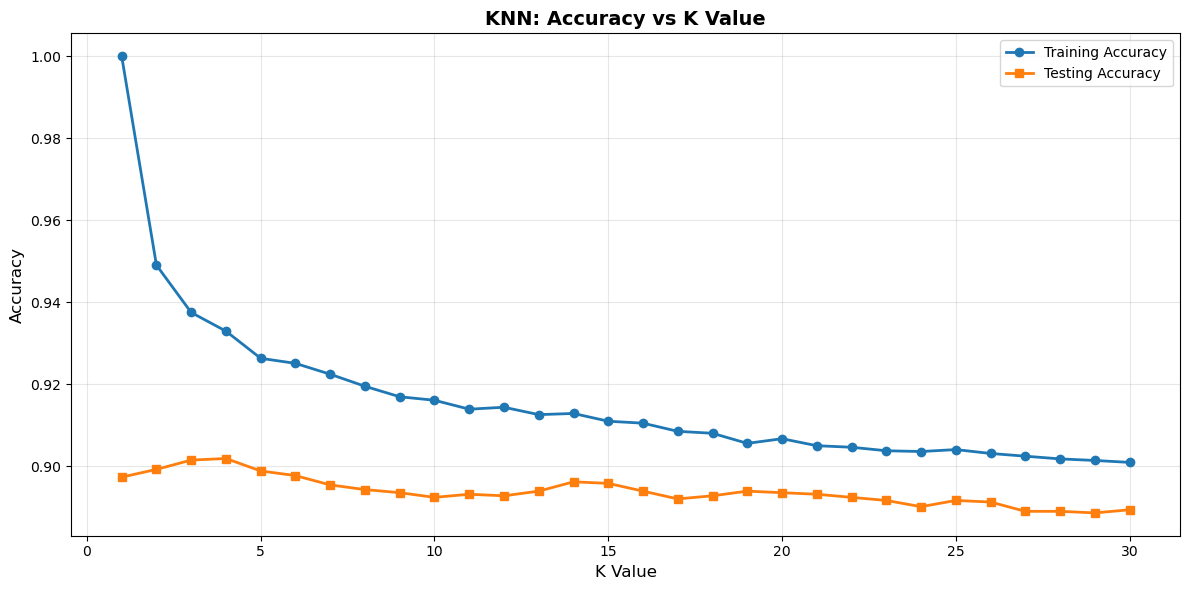



Optimal K Value: 4
Best Test Accuracy: 0.9019


In [9]:
# Testing berbagai nilai K untuk mencari yang optimal
k_range = range(1, 31)
train_scores = []
test_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_score = knn.score(X_train_scaled, y_train)
    test_score = knn.score(X_test_scaled, y_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    
    if k % 5 == 1:
        print(f"K={k}: Train Accuracy={train_score:.4f}, Test Accuracy={test_score:.4f}")

# Visualisasi hasil
plt.figure(figsize=(12, 6))
plt.plot(k_range, train_scores, label='Training Accuracy', marker='o', linewidth=2)
plt.plot(k_range, test_scores, label='Testing Accuracy', marker='s', linewidth=2)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN: Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Cari K optimal
optimal_k = k_range[test_scores.index(max(test_scores))]
print(f"\n\nOptimal K Value: {optimal_k}")
print(f"Best Test Accuracy: {max(test_scores):.4f}")

## 6. Training Model KNN dengan K Optimal

In [10]:
# Training model dengan K optimal
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred_train = knn_model.predict(X_train_scaled)
y_pred_test = knn_model.predict(X_test_scaled)

# Evaluasi
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Model KNN dengan K={optimal_k}")
print("="*50)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print("="*50)

Model KNN dengan K=4
Training Accuracy: 0.9330
Testing Accuracy: 0.9019


## 7. Evaluasi Model

Classification Report (Test Set):
              precision    recall  f1-score   support

      Cloudy       0.84      0.91      0.87       660
       Rainy       0.88      0.90      0.89       660
       Snowy       0.95      0.92      0.93       660
       Sunny       0.94      0.89      0.91       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



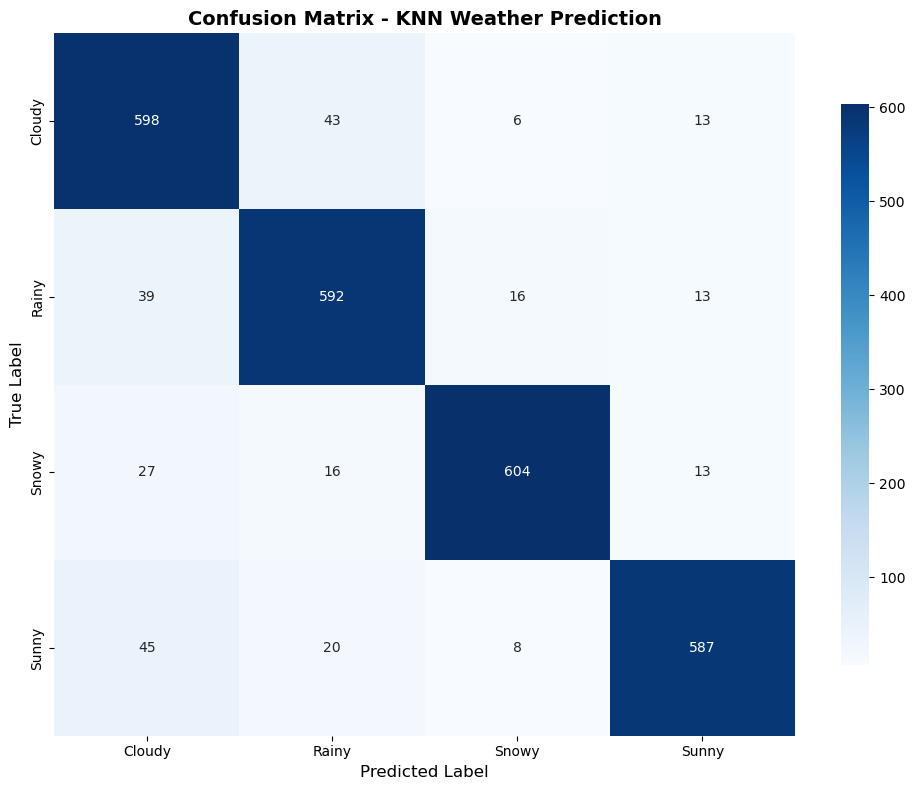

In [11]:
# Classification Report
print("Classification Report (Test Set):")
print("="*70)
print(classification_report(y_test, y_pred_test, target_names=le_target.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_,
            cbar_kws={"shrink": 0.8})
plt.title('Confusion Matrix - KNN Weather Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Cross-Validation

Cross-Validation Results (5-Fold):
Fold 1: 0.8991
Fold 2: 0.8982
Fold 3: 0.8996
Fold 4: 0.8925
Fold 5: 0.8982
Mean CV Score: 0.8975
Standard Deviation: 0.0026


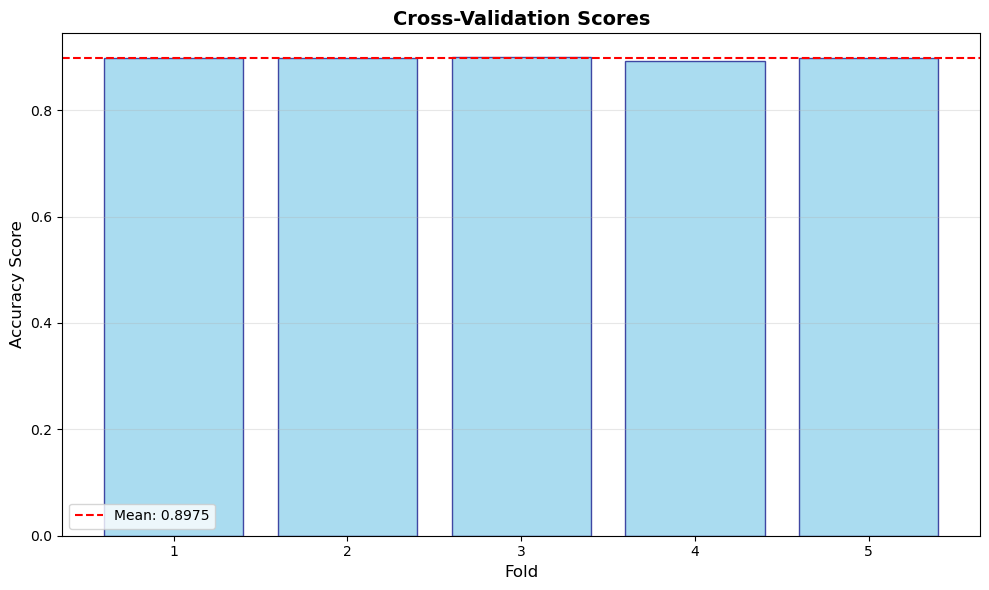

In [12]:
# Perform cross-validation
cv_scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=5)

print("Cross-Validation Results (5-Fold):")
print("="*50)
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")
print("="*50)
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

# Visualisasi CV scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_scores, color='skyblue', edgecolor='navy', alpha=0.7)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Cross-Validation Scores', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Hyperparameter Tuning dengan GridSearchCV

In [13]:
# Define parameter grid
param_grid = {
    'n_neighbors': range(3, 21, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Perform Grid Search
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, 
                           scoring='accuracy', n_jobs=-1, verbose=1)

print("Performing Grid Search...")
grid_search.fit(X_train_scaled, y_train)

# Results
print("\n\nBest Parameters:", grid_search.best_params_)
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Test best model
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)
best_test_accuracy = accuracy_score(y_test, y_pred_best)

print(f"\nBest Model Test Accuracy: {best_test_accuracy:.4f}")

Performing Grid Search...
Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best Parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV Score: 0.9006


Best Parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV Score: 0.9006

Best Model Test Accuracy: 0.8955

Best Model Test Accuracy: 0.8955


## 10. Prediksi dengan Data Baru

In [14]:
# Contoh prediksi dengan data baru
# Format: Temperature, Humidity, Wind Speed, Precipitation (%), Cloud Cover, 
#         Atmospheric Pressure, UV Index, Season, Visibility (km), Location

# Contoh 1: Kondisi cuaca cerah
data_baru_1 = {
    'Temperature': 28,
    'Humidity': 45,
    'Wind Speed': 5.0,
    'Precipitation (%)': 10,
    'Cloud Cover': 'clear',
    'Atmospheric Pressure': 1020.0,
    'UV Index': 8,
    'Season': 'Summer',
    'Visibility (km)': 10.0,
    'Location': 'coastal'
}

# Contoh 2: Kondisi cuaca hujan
data_baru_2 = {
    'Temperature': 15,
    'Humidity': 85,
    'Wind Speed': 12.0,
    'Precipitation (%)': 80,
    'Cloud Cover': 'overcast',
    'Atmospheric Pressure': 995.0,
    'UV Index': 2,
    'Season': 'Winter',
    'Visibility (km)': 3.0,
    'Location': 'inland'
}

# Contoh 3: Kondisi cuaca bersalju
data_baru_3 = {
    'Temperature': -5,
    'Humidity': 90,
    'Wind Speed': 15.0,
    'Precipitation (%)': 85,
    'Cloud Cover': 'overcast',
    'Atmospheric Pressure': 985.0,
    'UV Index': 1,
    'Season': 'Winter',
    'Visibility (km)': 2.0,
    'Location': 'mountain'
}

# Fungsi untuk melakukan prediksi
def predict_weather(data_dict):
    # Convert to DataFrame
    df_new = pd.DataFrame([data_dict])
    
    # Encode categorical features
    for col in categorical_cols:
        df_new[col] = label_encoders[col].transform(df_new[col])
    
    # Reorder columns to match training data
    df_new = df_new[X.columns]
    
    # Scale features
    df_new_scaled = scaler.transform(df_new)
    
    # Predict
    prediction = best_knn.predict(df_new_scaled)
    prediction_proba = best_knn.predict_proba(df_new_scaled)
    
    # Decode prediction
    weather_type = le_target.inverse_transform(prediction)[0]
    
    return weather_type, prediction_proba[0]

# Prediksi untuk setiap contoh
print("Prediksi Cuaca dengan Model KNN")
print("="*70)

for i, data in enumerate([data_baru_1, data_baru_2, data_baru_3], 1):
    print(f"\nContoh {i}:")
    print(f"  Temperature: {data['Temperature']}°C")
    print(f"  Humidity: {data['Humidity']}%")
    print(f"  Wind Speed: {data['Wind Speed']} km/h")
    print(f"  Precipitation: {data['Precipitation (%)']}%")
    print(f"  Cloud Cover: {data['Cloud Cover']}")
    
    weather, proba = predict_weather(data)
    print(f"\n  Prediksi: {weather}")
    print(f"  Probabilitas:")
    for j, class_name in enumerate(le_target.classes_):
        print(f"    {class_name}: {proba[j]:.4f}")
    print("-"*70)

Prediksi Cuaca dengan Model KNN

Contoh 1:
  Temperature: 28°C
  Humidity: 45%
  Wind Speed: 5.0 km/h
  Precipitation: 10%
  Cloud Cover: clear

  Prediksi: Sunny
  Probabilitas:
    Cloudy: 0.0000
    Rainy: 0.0000
    Snowy: 0.0000
    Sunny: 1.0000
----------------------------------------------------------------------

Contoh 2:
  Temperature: 15°C
  Humidity: 85%
  Wind Speed: 12.0 km/h
  Precipitation: 80%
  Cloud Cover: overcast

  Prediksi: Rainy
  Probabilitas:
    Cloudy: 0.0000
    Rainy: 1.0000
    Snowy: 0.0000
    Sunny: 0.0000
----------------------------------------------------------------------

Contoh 3:
  Temperature: -5°C
  Humidity: 90%
  Wind Speed: 15.0 km/h
  Precipitation: 85%
  Cloud Cover: overcast

  Prediksi: Snowy
  Probabilitas:
    Cloudy: 0.0000
    Rainy: 0.0000
    Snowy: 1.0000
    Sunny: 0.0000
----------------------------------------------------------------------
